# 01 · Does a region need the network to reproduce itself?

*Task 01 of the final series. The base model is fixed here, and every later task inherits
it from `final/base_model.yaml`.*

The question is asked by trying, not by lesioning: each region is fitted **alone**, in every
**pair**, in every **triple**, and in the **full network** — eight fits per region — and its
reproduction of its own trajectories is followed up the ladder. Every rung uses the same
40-unit region with the same 42-component readout, so the rank cap on what a region *can*
express is identical at every rung, and any gain from adding partners is dynamical rather
than a readout artefact.

**Two things distinguish this series from the `chapter/` rebuild, and both are in the base
model.**

*The objective is minimax.* Every region × condition cell is scored by its unexplained
fraction — scale-free in both region and condition — and the loss is the worst cell. A
weighted sum lets the optimiser buy a better fit on one fixation type by sacrificing another,
and which one it sacrifices is set by the weights (uniform: interactive face; balanced: the
other two). Under minimax all twelve cells degrade together when capacity is removed, no
region dominates by having more units, and "does every fixation type reach the ceiling" is a
property of the objective rather than a hope. It is the chapter's adequacy criterion —
worst cell against the ceiling — used as the loss.

*The R² is centred the way the ceiling is.* The noise ceiling is a per-component split-half
correlation over the pooled (condition × time) trajectory; the fit is now scored with SST
centred per component over the same pooled trajectory. The earlier grand-mean centring was
mismatched to it.

**Two metrics, because total R² hides where the network acts.** A region alone reproduces its
slow envelope almost perfectly and its fast structure badly; the network's contribution is
concentrated at 5–20 Hz. So each rung is scored on R² against the ceiling *and* on the
fraction of target power left in the residual, per frequency band.

| Section | |
|---|---|
| 1 | The base model, frozen |
| 2 | The rungs — 15 configurations |
| 3 | Run state and submission (off by default) |
| 4 | Convergence and fit against the ceiling |
| 5 | The ladder: each region against the number of partners |
| 6 | Which partner helps whom |
| 7 | Where the network acts: band-resolved recovery |
| 8 | Every fixation type, every rung |
| 9 | Reading the result |

**Nothing here submits a job unless `SUBMIT` is set to `True`.**

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_sweep as viz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
MRNN_CFG_PATH = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

TREE = "final"
PROTOCOL_ROOT = protocol.resolve_chapter_root(DATASET_CFG_PATH, task="00_training_protocol")
TASK_ROOT = sweep.resolve_task_root("01_ladder", DATASET_CFG_PATH, tree=TREE)
SERIES_ROOT = TASK_ROOT.parent
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_01_ladder")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

SELECTED_PROTOCOL, PROTOCOL_IS_PROVISIONAL = sweep.load_selected_protocol_or_provisional(
    PROTOCOL_ROOT / "selected_protocol.yaml"
)
REGION_ORDER = ("ofc", "bla", "dmpfc", "accg")

#: The objective. "minimax" is what the header argues for; "sum" with balanced weighting is
#: the chapter/ objective, kept as a one-line fallback.
LOSS_AGGREGATION = "minimax"
MINIMAX_TEMPERATURE = 0.01

#: The base model every task in this series inherits. Written to final/base_model.yaml on
#: every run of this cell so the file is always the current definition.
BASE_MODEL = {
    "hidden_units": 40,
    "recurrent_connectivity": "full",
    "recurrent_bottleneck_dim": None,
    "within_region_bottleneck_dim": None,
    "l1_weight_scale": 0.0,
    "loss_aggregation": LOSS_AGGREGATION,
    "minimax_temperature": MINIMAX_TEMPERATURE,
    # Under minimax the per-cell normalisation does the balancing; stacking a condition
    # weighting on top would double-count. Under "sum" the balanced weighting is what
    # task 02 of the rebuild established.
    "condition_loss_weighting": "uniform" if LOSS_AGGREGATION == "minimax" else "balanced",
    "pc_loss_weighting": "uniform",
}
SERIES_ROOT.mkdir(parents=True, exist_ok=True)
(SERIES_ROOT / "base_model.yaml").write_text(yaml.safe_dump({
    **BASE_MODEL, "inherited_protocol": SELECTED_PROTOCOL["selected_label"],
    "region_order": list(REGION_ORDER), "r2_centring": "per component over pooled condition x time",
}, sort_keys=False))

#: Seeds. Five per sub-network is enough to put an interval on each rung; ten for the full
#: network, because it is also the dense baseline task 03's ensemble is compared against.
LADDER_SEEDS = 5
FULL_SEEDS = 10
#: Adequacy bar on the **matched** ceiling. Its noise control sits at about +/-0.01, so a
#: bar within 0.01 of 1 is inside the ceiling's own error; 0.98 is the tightest bar the
#: ceiling can support. 0.99 is reported alongside for continuity with the rebuild.
ADEQUATE_BAR = 0.98
STRICT_BAR = 0.99

#: The chapter's ceiling: one number per region, an unweighted mean over 42 per-component
#: reliabilities in a basis fitted on half A. Kept for comparison only.
old_ceiling_by_region = (
    pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
    .groupby("region")["reliability"].mean().to_dict()
)

#: The matched ceiling: per region x condition, in the model's own PCA basis, centred as the
#: R^2 is, variance-weighted as the R^2 is. Computed once from the stored split-half traces
#: and any trained checkpoint (they all share the same targets), cached for the series.
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_analysis import replay_fixation_mrnn_run

CEILING_CELL_PATH = SERIES_ROOT / "pc_space_ceiling_by_cell.csv"
if not CEILING_CELL_PATH.exists() and audit.seed_run_dirs(TASK_ROOT / "full"):
    _ck = replay_fixation_mrnn_run(audit.seed_run_dirs(TASK_ROOT / "full")[0], device="cpu")["checkpoint"]
    ceiling_mod.population_ceiling_by_cell(
        pd.read_pickle(CEILING_DIR / "unit_noise_ceiling.pkl"),
        pca_by_region=_ck["pca_by_region"], normalization_scale=_ck["normalization_scale"],
        conditions=[str(c) for c in _ck["condition_order"]],
    ).to_csv(CEILING_CELL_PATH, index=False)
ceiling_cell = pd.read_csv(CEILING_CELL_PATH) if CEILING_CELL_PATH.exists() else None
ceiling_by_region = (ceiling_cell[ceiling_cell["condition"] == "all"].set_index("region")["reliability"].to_dict()
                     if ceiling_cell is not None else old_ceiling_by_region)
ceiling_by_cell = ({(r, c): v for r, c, v in ceiling_cell[ceiling_cell["condition"] != "all"]
                    [["region", "condition", "reliability"]].itertuples(index=False)}
                   if ceiling_cell is not None else None)


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists():
        return pd.read_csv(path)
    frame = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame


print("recipe    :", SELECTED_PROTOCOL["selected_label"])
print("objective :", LOSS_AGGREGATION)
print("task root :", TASK_ROOT)

recipe    : lr0p0003_cosine_clip0p05_tanh_sr1p1
objective : minimax
task root : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/final/01_ladder


## 1. The base model, frozen

| | value | why |
|---|---|---|
| width | 40 units / region | the readout is 42 components; rank(target) ≈ 39, so this is the minimum that can express it (rebuild task 06, E1). Constant across every rung. |
| recipe | lr 3e-4, cosine, clip 0.05, tanh, sr 1.1, 100k | rebuild task 00: the only configuration with zero failures and final = best iterate |
| objective | **minimax** over 12 region × condition cells, τ = 0.01 | see header; replaces balanced condition weighting |
| R² | centred per component over pooled condition × time | matches the ceiling's own centring |
| adequacy | worst cell ≥ 0.99 of ceiling | the criterion the objective optimises |

Written to `final/base_model.yaml`; tasks 02 and 03 read it rather than restating it.

### The ceiling, matched to the R²

The rebuild divided every R² by one number per region: an unweighted mean over 42
per-component split-half reliabilities, in a basis fitted on half of the trials, pooled over
conditions. Three mismatches with the R² it was dividing:

- the model is scored in the PCA basis fitted on the **full** average;
- R² sums squared error over components, so it is **variance-weighted** — dominated by the
  leading components at ~0.999 — while the unweighted mean is pulled down by the tail at
  0.91–0.95. That is why R²/ceiling came out above 1 (387 of 540 cells in this ladder);
- interactive face has five times the trials of the others and a genuinely higher ceiling.

The matched ceiling projects the two independent half-averages onto the model's own basis,
centres per component over the pooled trajectory exactly as the R² does, correlates the
**whole trajectory** (variance-weighted by construction), and does this per region ×
condition. The stored half-traces reproduce the training target to 4 × 10⁻³ — they are the
model's own data, in spikes-per-bin rather than Hz. Noise control ≈ 0.

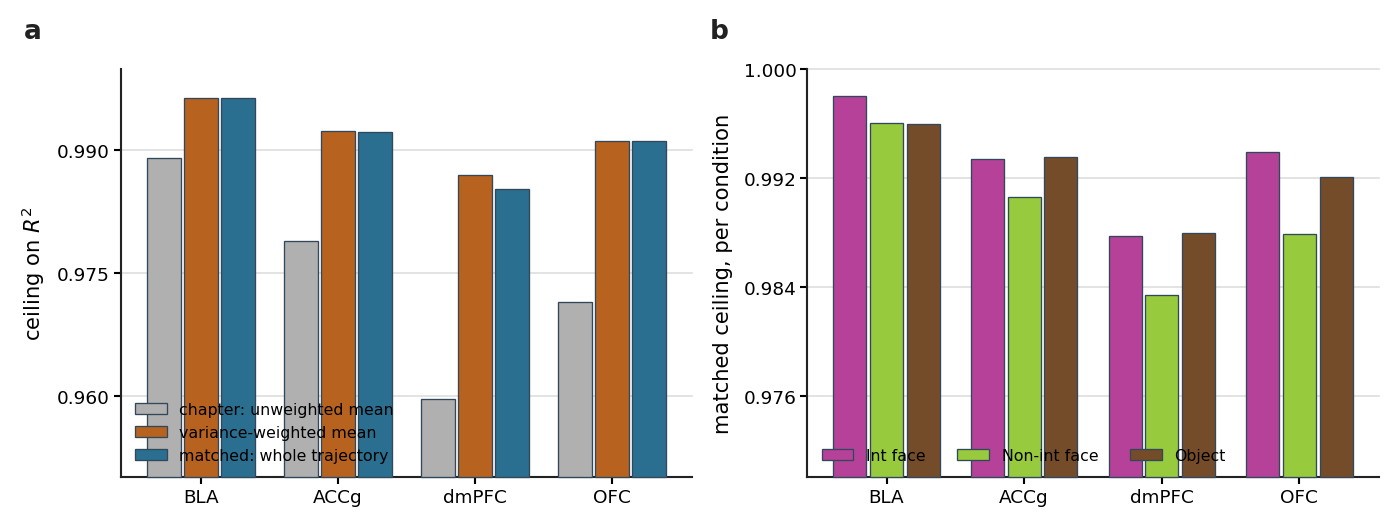

condition,all,face_interactive,face_non_interactive,object
region,,,,
accg,0.9923,0.9934,0.9906,0.9935
bla,0.9964,0.9980,0.9960,0.9959
dmpfc,0.9853,0.9877,0.9834,0.9879
ofc,0.9911,0.9939,0.9879,0.9920


In [2]:
if ceiling_cell is not None:
    show(aviz.plot_ceiling_comparison(ceiling_cell, old_ceiling_by_region), "fig00_ceiling_matched")
    display(ceiling_cell.pivot(index="region", columns="condition", values="reliability").round(4))
else:
    display(Markdown("*The matched ceiling needs one trained checkpoint; it is computed once `full` exists.*"))

## 2. The rungs

Every non-empty subset of the four regions: 4 singles, 6 pairs, 4 triples, the full network.
A subset is a `region_order` override; the target builder fits each region's PCA on its own
units and pools the normalisation scale over all four recorded regions, so **a region's
target is bit-identical at every rung** — verified during the smoke test, `max|Δ| = 0`.

In [3]:
variants = audit.ladder_variants(REGION_ORDER, base_overrides=BASE_MODEL)
sub_variants = [v for v in variants if v.label != "full"]
full_variant = [v for v in variants if v.label == "full"]
ladder_seeds = protocol.protocol_seeds(n_seeds=LADDER_SEEDS)
full_seeds = protocol.protocol_seeds(n_seeds=FULL_SEEDS)

table = pd.DataFrame([{"label": v.label, "arm": v.arm, "regions": " ".join(v.overrides["region_order"]),
                       "seeds": FULL_SEEDS if v.label == "full" else LADDER_SEEDS} for v in variants])
display(table)
display(Markdown(
    f"**{len(sub_variants)} sub-networks × {LADDER_SEEDS} seeds + full × {FULL_SEEDS} = "
    f"{len(sub_variants) * LADDER_SEEDS + FULL_SEEDS} runs.**"))

,label,arm,regions,seeds
0,single_ofc,alone,ofc,5
1,single_bla,alone,bla,5
2,single_dmpfc,alone,dmpfc,5
3,single_accg,alone,accg,5
4,pair_ofc_bla,pair,ofc bla,5
5,pair_ofc_dmpfc,pair,ofc dmpfc,5
6,pair_ofc_accg,pair,ofc accg,5
7,pair_bla_dmpfc,pair,bla dmpfc,5
8,pair_bla_accg,pair,bla accg,5
9,pair_dmpfc_accg,pair,dmpfc accg,5


**14 sub-networks × 5 seeds + full × 10 = 80 runs.**

In [4]:
SUBMIT = False   # <-- set to True to queue every missing run as one array

flight = sweep.in_flight_run_dirs(TASK_ROOT / "_jobs")
cmd_sub, _ = sweep.variant_job_commands(
    sub_variants, ladder_seeds, root=TASK_ROOT, repo_root=repo_root,
    protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH, exclude_run_dirs=flight["run_dirs"])
cmd_full, _ = sweep.variant_job_commands(
    full_variant, full_seeds, root=TASK_ROOT, repo_root=repo_root,
    protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH, exclude_run_dirs=flight["run_dirs"])
commands = list(cmd_sub) + list(cmd_full)

inventory = pd.concat([
    sweep.index_variant_runs(TASK_ROOT, sub_variants, ladder_seeds, in_flight=flight["run_dirs"]),
    sweep.index_variant_runs(TASK_ROOT, full_variant, full_seeds, in_flight=flight["run_dirs"]),
], ignore_index=True)
display(Markdown(
    f"**{int(inventory['complete'].sum())} complete**, **{int(inventory['queued'].sum())} queued**, "
    f"**{int(inventory['pending'].sum())} unqueued** of {len(inventory)}."))

if SUBMIT and commands:
    from datetime import datetime
    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir = TASK_ROOT / "_jobs"
    jobs_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    job_file = jobs_dir / f"ladder_{stamp}.txt"
    write_job_file(job_file, commands)
    submitted = [Path(line.split("--run-dir ")[1].split()[0]) for line in commands]
    job_id = submit_dsq_array_job(
        job_file_path=job_file, sbatch_script_path=jobs_dir / f"ladder_{stamp}.sh",
        log_dir=jobs_dir / "logs", job_name="mrnn_ladder", partition="psych_gpu",
        cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
    )
    sweep.record_submission(jobs_dir, job_id=job_id, run_dirs=submitted, label=f"ladder {stamp}")
    (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
    display(Markdown(f"Submitted **{len(commands)}** runs as array **{job_id}**."))
elif commands:
    display(Markdown("`SUBMIT` is **False** — nothing was submitted."))
else:
    display(Markdown("Every rung is trained."))

**80 complete**, **0 queued**, **0 unqueued** of 80.

Every rung is trained.

## 4. Convergence and fit

Convergence first. Under minimax the history carries `worst_cell_unexplained` directly, so
the convergence curve and the adequacy criterion are the same quantity.

In [5]:
done = inventory[inventory["complete"]]
if done.empty:
    display(Markdown("*Nothing trained yet.*"))
    fit = None
else:
    display(sweep.convergence_table(sweep.load_histories(done)).round(5))
    fit = cached("ladder_fit_matched", lambda: audit.annotate_ladder(
        sweep.score_variant_fit(done, ceiling_by_region, ceiling_by_cell=ceiling_by_cell), REGION_ORDER))
    fit["partners"] = fit["partners"].astype(str)
    summary = (fit.groupby(["label", "n_partners"])["r2_vs_ceiling"]
               .agg(mean="mean", worst="min").reset_index().sort_values(["n_partners", "label"]))
    display(summary.round(4))
    worst_per_fit = fit.groupby(["label", "seed"])["r2_vs_ceiling"].min().reset_index().merge(
        fit.groupby("label")["n_partners"].first().reset_index(), on="label")
    clears = worst_per_fit.groupby("n_partners").apply(
        lambda d: pd.Series({f"clear {ADEQUATE_BAR}": f"{int((d['r2_vs_ceiling'] >= ADEQUATE_BAR).sum())}/{len(d)}",
                             f"clear {STRICT_BAR}": f"{int((d['r2_vs_ceiling'] >= STRICT_BAR).sum())}/{len(d)}"}))
    display(Markdown("**Fits clearing the bar, by rung (worst region × condition cell):**"))
    display(clears)

,label,n_seeds,n_converged,worst_late_spikes,worst_final_over_best,median_best_loss,best_loss_spread
0,single_ofc,5,5,0,1.00001,0.05472,1.09484
1,single_bla,5,5,0,1.00003,0.04940,1.05895
2,single_dmpfc,5,5,0,1.00000,0.05646,1.17792
3,single_accg,5,5,0,1.00006,0.06532,1.29715
4,pair_ofc_bla,5,5,0,1.00000,0.04165,1.06316
5,pair_ofc_dmpfc,5,5,0,1.00002,0.04512,1.05249
6,pair_ofc_accg,5,5,0,1.00000,0.04762,1.08408
7,pair_bla_dmpfc,5,5,0,1.00000,0.04232,1.10147
8,pair_bla_accg,5,5,0,1.00001,0.04445,1.04444
9,pair_dmpfc_accg,5,5,0,1.00001,0.04874,1.08629


,label,n_partners,mean,worst
7,single_accg,0,0.9675,0.9536
8,single_bla,0,0.9752,0.9672
9,single_dmpfc,0,0.9812,0.9727
10,single_ofc,0,0.9780,0.9690
1,pair_bla_accg,1,0.9871,0.9814
2,pair_bla_dmpfc,1,0.9914,0.9817
3,pair_dmpfc_accg,1,0.9893,0.9819
4,pair_ofc_accg,1,0.9869,0.9802
5,pair_ofc_bla,1,0.9893,0.9820
6,pair_ofc_dmpfc,1,0.9921,0.9842


/tmp/ipykernel_598303/2074574304.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clears = worst_per_fit.groupby("n_partners").apply(


**Fits clearing the bar, by rung (worst region × condition cell):**

,clear 0.98,clear 0.99
n_partners,,
0,1/20,0/20
1,30/30,0/30
2,20/20,3/20
3,10/10,9/10


### Loss trajectories

Under minimax the total loss *is* the worst cell's unexplained fraction (softly), so these
curves are the adequacy criterion over training. Every rung, every seed.

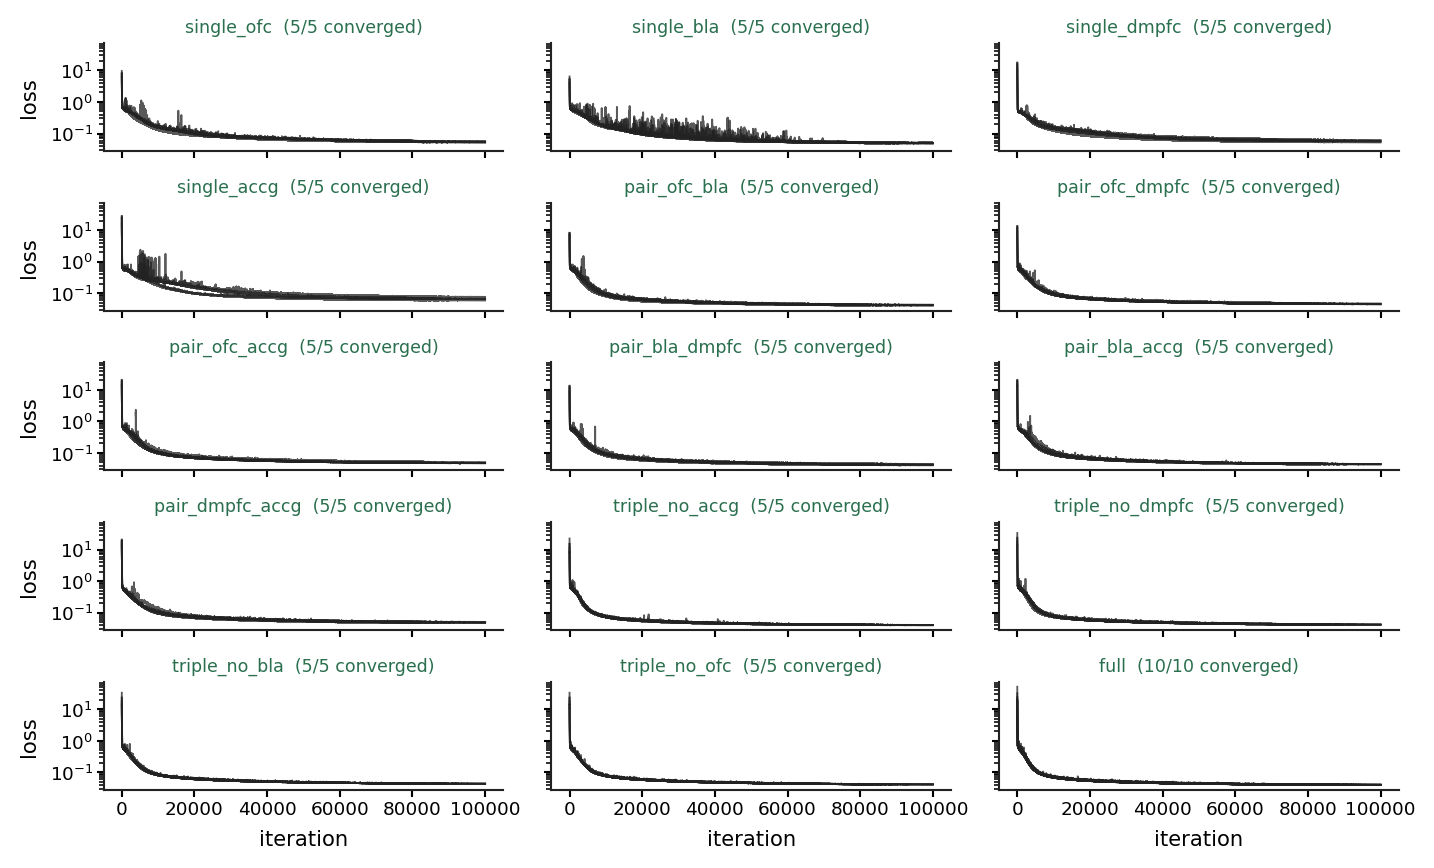

In [6]:
if fit is not None:
    histories = sweep.load_histories(done)
    order = [v.label for v in variants]
    show(viz.plot_sweep_loss_trajectories({k: histories[k] for k in order if k in histories},
                                          convergence=sweep.convergence_table(histories)),
         "fig01b_loss_trajectories")

## 5. The ladder

Each panel is one region; the x-axis is how many other regions it was fitted alongside.
Every point is one fit, every line the mean per rung. The dashed line is the adequacy bar.

Read the slope. A region that reaches the bar alone did not need the network; one that
climbs to it needed exactly what the partners supplied.

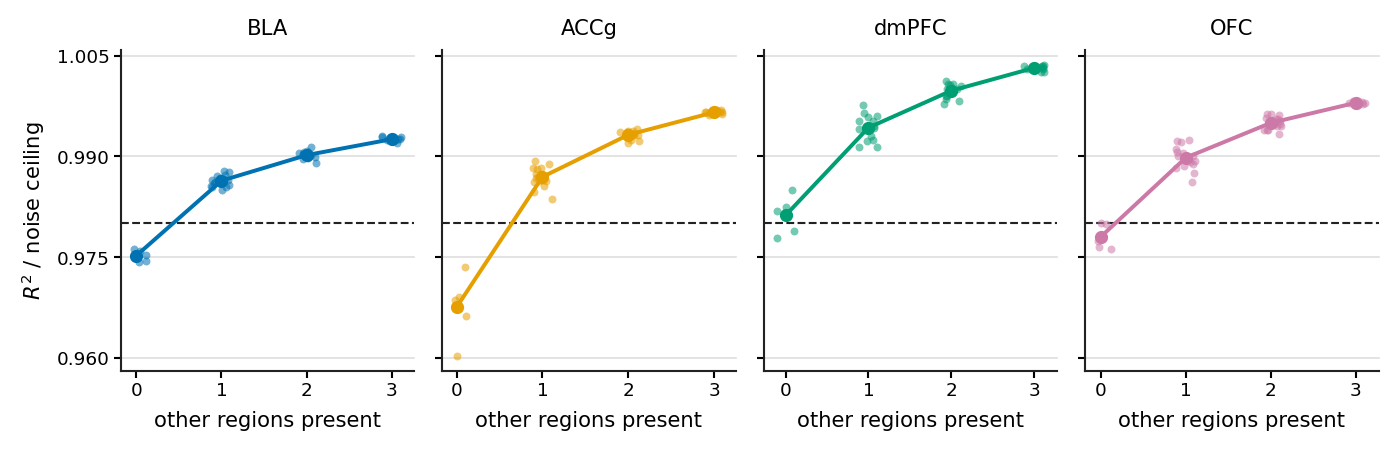

n_partners,0,1,2,3,gain_alone_to_full
region,,,,,
accg,0.9675,0.9870,0.9932,0.9966,0.0290
bla,0.9752,0.9864,0.9902,0.9926,0.0174
dmpfc,0.9812,0.9943,0.9998,1.0032,0.0220
ofc,0.9780,0.9898,0.9950,0.9980,0.0200


In [7]:
if fit is not None:
    show(aviz.plot_ladder_curves(fit, adequate_bar=ADEQUATE_BAR), "fig01_ladder")
    rungs = fit.groupby(["region", "n_partners"])["r2_vs_ceiling"].mean().unstack("n_partners")
    rungs["gain_alone_to_full"] = rungs[3] - rungs[0]
    display(rungs.round(4))

## 6. Which partner helps whom

At the first rung the attribution is unambiguous: the gain from a pair over the single is the
contribution of exactly one partner. Rows are the region scored, columns the partner added.

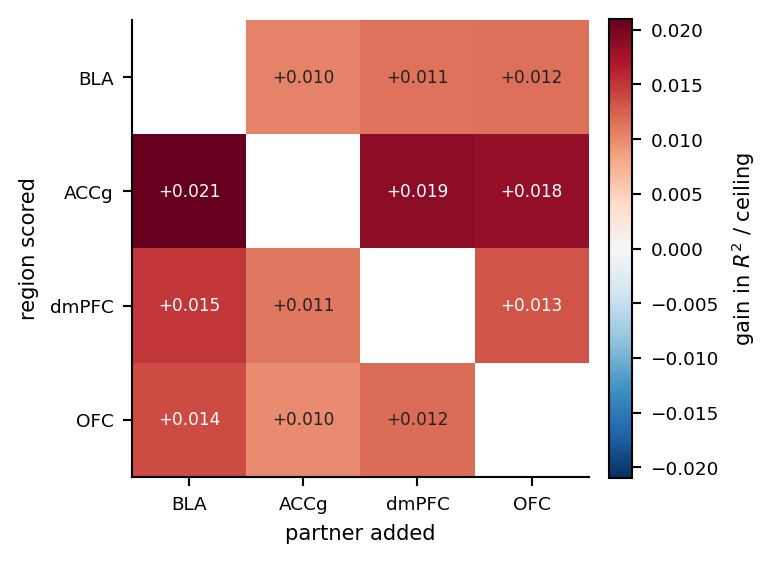

In [8]:
if fit is not None and (fit["n_partners"] == 1).any():
    fit_tuples = fit.copy()
    fit_tuples["partners"] = fit_tuples["partners"].map(
        lambda s: tuple(x.strip(" '") for x in str(s).strip("()").split(",") if x.strip(" '")))
    show(aviz.plot_partner_matrix(fit_tuples), "fig02_partner_matrix")

## 7. Where the network acts

Fraction of the target's power, per frequency band, that the fit fails to reproduce. In the
rebuild's isolation arms a region alone left two-thirds of its 10–20 Hz power unreproduced
and the network cut that to a quarter, while the 0–5 Hz band was reproduced either way. This
is the ladder scored on that quantity.

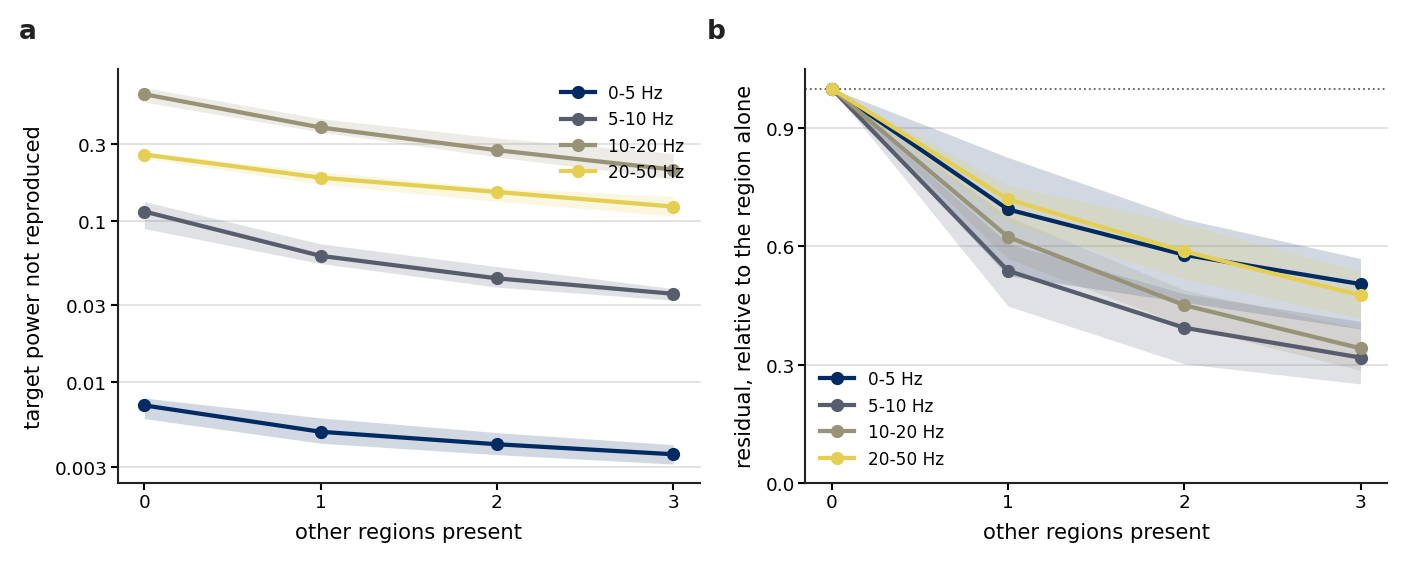

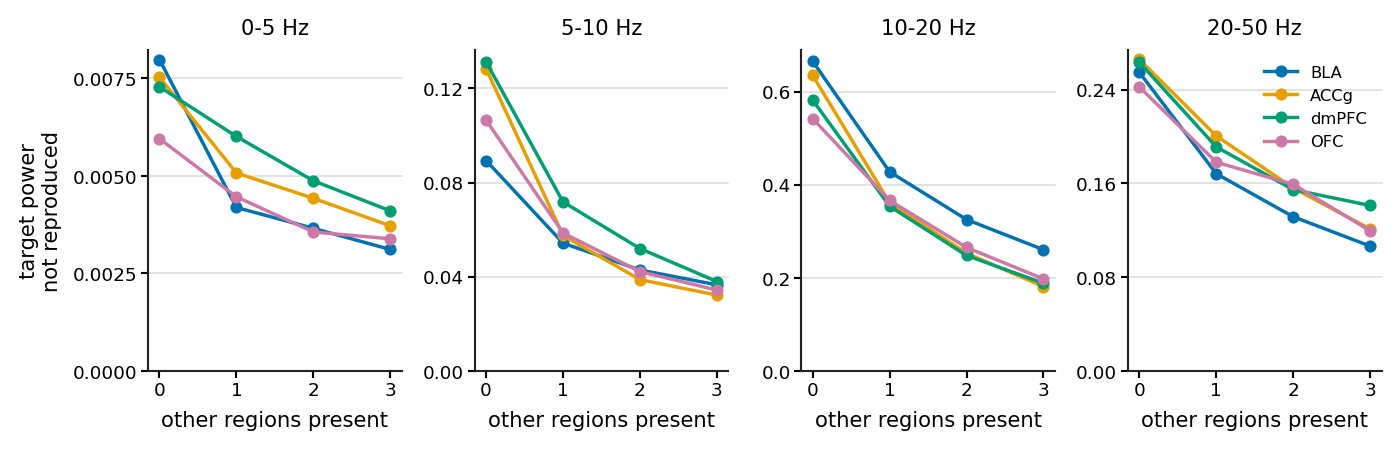

n_partners,0,1,2,3
band,,,,
0-5 Hz,0.007,0.005,0.004,0.004
10-20 Hz,0.606,0.377,0.273,0.207
20-50 Hz,0.257,0.185,0.150,0.122
5-10 Hz,0.114,0.061,0.044,0.035


In [9]:
if fit is not None:
    recovery = cached("band_recovery", lambda: pd.concat(
        [audit.band_resolved_recovery(r.run_dir).assign(label=r.label) for r in done.itertuples()],
        ignore_index=True))
    partners = fit.groupby(["label", "region"])["n_partners"].first().reset_index()
    recovery = recovery.merge(partners, on=["label", "region"], how="inner")
    show(aviz.plot_band_recovery_pooled(recovery), "fig03_band_recovery_pooled")
    show(aviz.plot_band_recovery_by_rung(recovery), "fig03b_band_recovery_by_region")
    display(recovery.groupby(["band", "n_partners"])["residual_fraction"].mean().unstack("n_partners").round(3))

## 8. Every fixation type, every rung

Under minimax the three conditions should sit close together at every rung — that is what the
objective enforces. This is the check, and it is also the honest replacement for "which
fixation type is damaged most": under a minimax objective they degrade together by
construction, so the per-condition ordering is not a question a fitted model can answer.
The per-condition facts that are real live in the data (rebuild task 07, §6).

mean                                           min  \
condition  face_interactive face_non_interactive  object face_interactive   
n_partners                                                                  
0                    0.9697               0.9804  0.9764           0.9536   
1                    0.9858               0.9930  0.9893           0.9802   
2                    0.9921               0.9976  0.9939           0.9868   
3                    0.9959               1.0003  0.9966           0.9899   

                                         
condition  face_non_interactive  object  
n_partners                               
0                        0.9664  0.9606  
1                        0.9870  0.9827  
2                        0.9905  0.9897  
3                        0.9929  0.9926

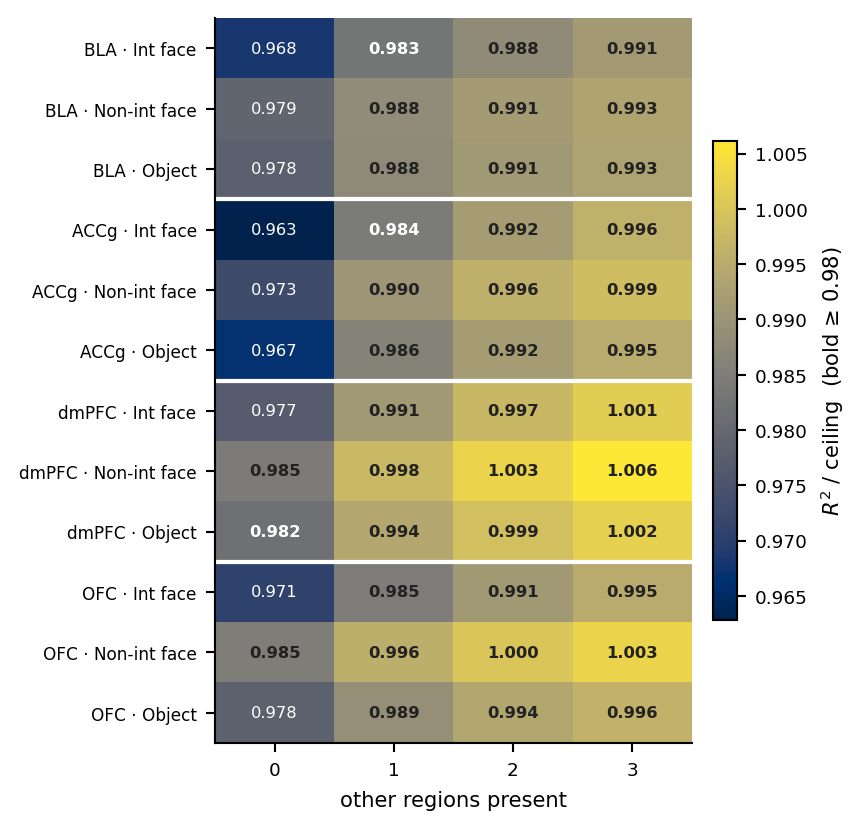

At the single-region rung, interactive face is the lowest condition in **20/20** region × seed fits (mean gap to non-interactive face -0.0108).

In [10]:
if fit is not None:
    per_cond = fit.groupby(["n_partners", "condition"])["r2_vs_ceiling"].agg(["mean", "min"]).unstack("condition")
    display(per_cond.round(4))
    show(aviz.plot_ladder_cell_heatmap(fit, bar=ADEQUATE_BAR), "fig04_cell_heatmap")
    rung0 = fit[fit["n_partners"] == 0].groupby(["region", "seed", "condition"])["r2_vs_ceiling"].mean().unstack("condition")
    display(Markdown(
        f"At the single-region rung, interactive face is the lowest condition in "
        f"**{int((rung0.idxmin(axis=1) == 'face_interactive').sum())}/{len(rung0)}** region × seed fits "
        f"(mean gap to non-interactive face {(rung0['face_interactive'] - rung0['face_non_interactive']).mean():+.4f})."))

## 8b. What the fits look like

One row per rung for the most network-dependent region, the same three components
throughout, target against model. A rank can look free in R² and still visibly smooth a
trajectory; this is the check that the gains up the ladder are real structure.

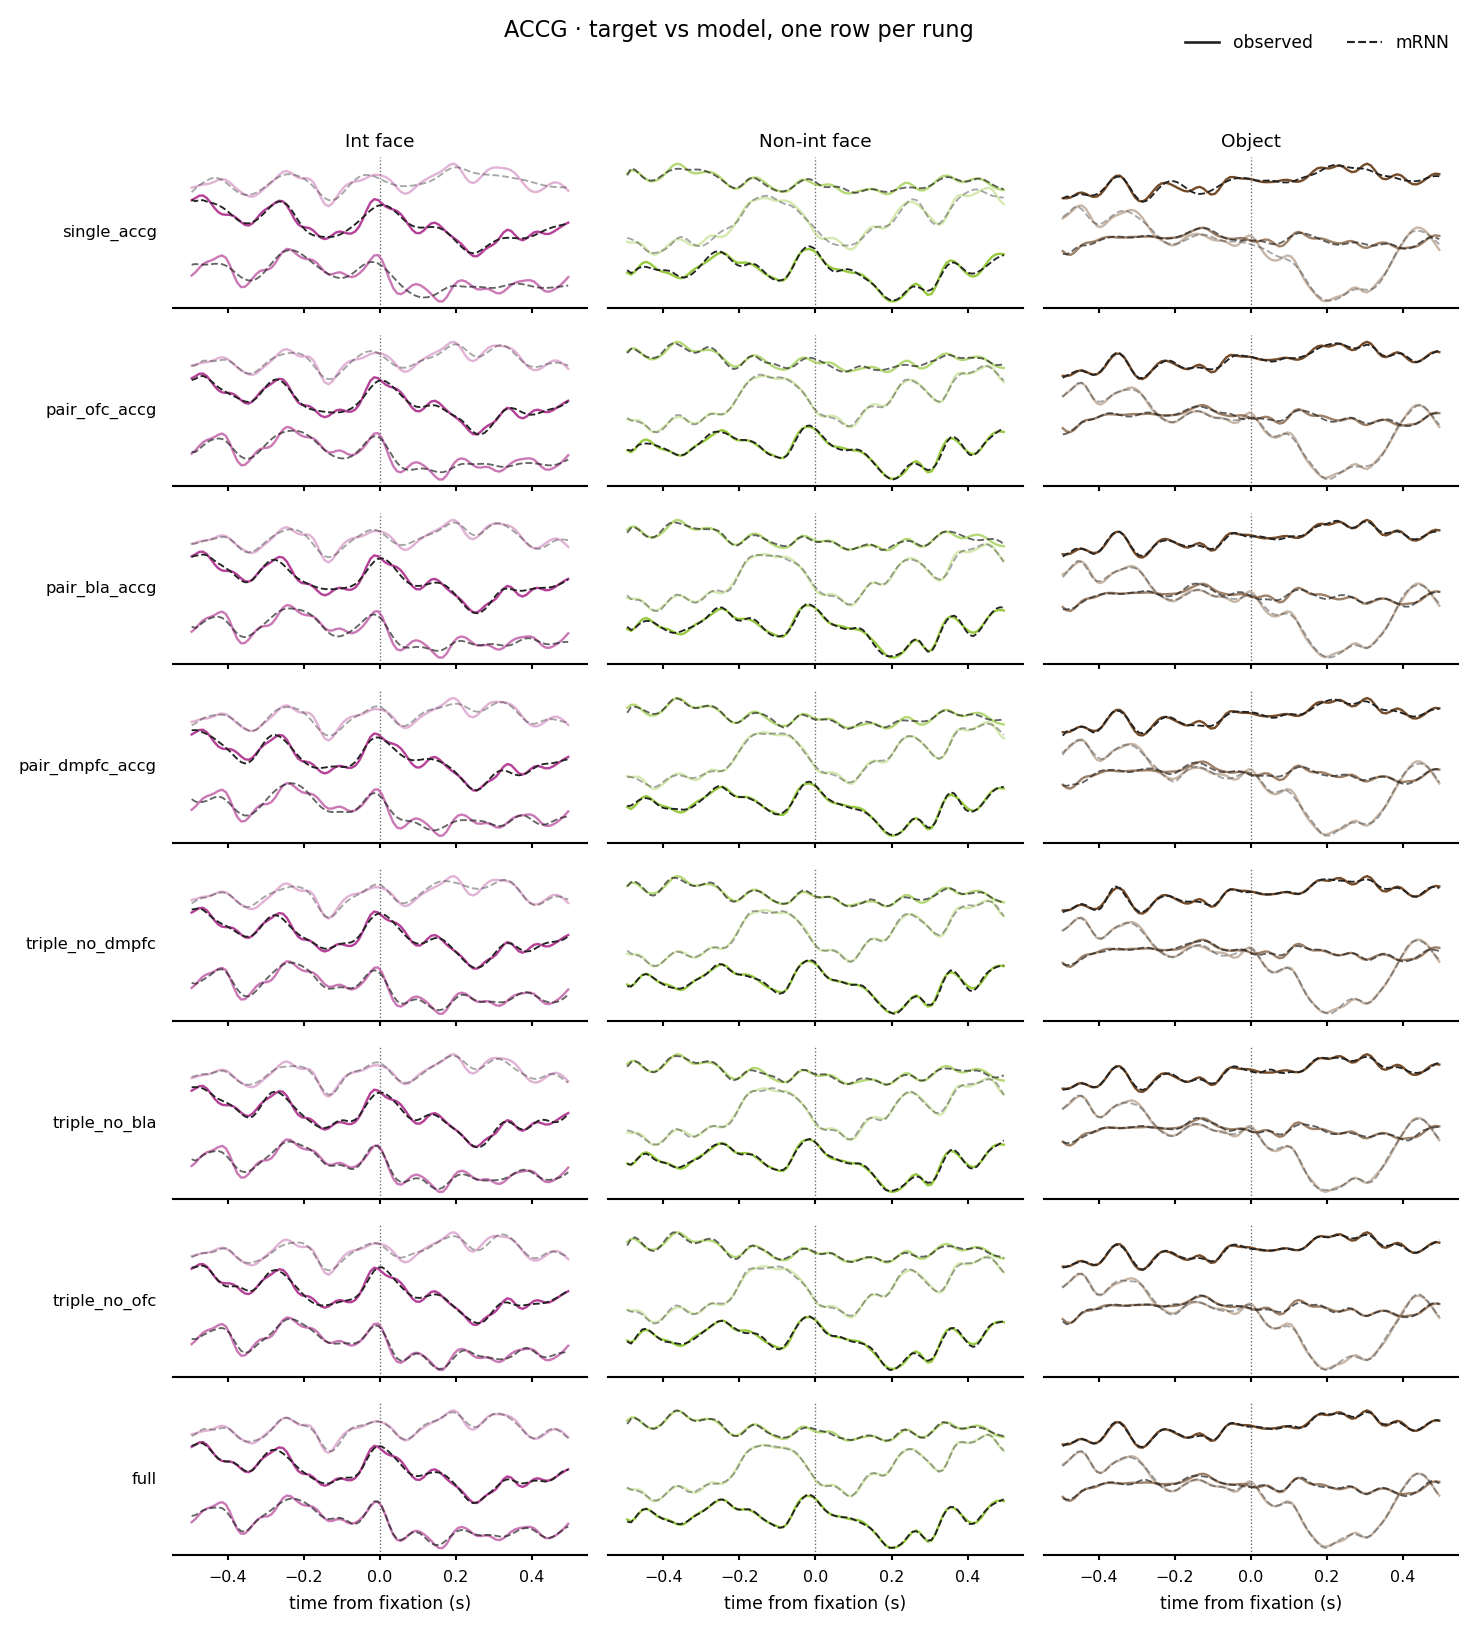

In [11]:
if fit is not None:
    GALLERY_REGION = "accg"
    gallery_labels = [v.label for v in variants if GALLERY_REGION in v.overrides["region_order"]]
    gallery_inventory = done[done["label"].isin(gallery_labels)]
    traces = cached("gallery_traces_accg", lambda: sweep.gallery_traces(gallery_inventory, region=GALLERY_REGION))
    show(viz.plot_fit_gallery(traces, order=gallery_labels, title=f"{GALLERY_REGION.upper()} · target vs model, one row per rung"),
         "fig05_gallery_accg")

## 9. Reading the result

Three statements this task can support, in order of what they would mean:

1. **Whether a region reproduces itself alone.** The single rung against the bar, per
   region. If all four clear it alone, the network is not *needed* for reproduction and the
   ladder's slope is the size of what it adds; if some do not, those are the regions whose
   trajectories are not autonomous at this width.
2. **Where the network acts.** The band-resolved panels. If the slow band is flat and the
   fast bands fall with partners, the network supplies fast structure a region cannot
   generate alone — a claim about *what* inter-regional input carries, made without reading
   a single weight.
3. **Which partner supplies it.** The pair matrix, if the gains separate. If they do not,
   the network's contribution is distributed and the chapter says so.

**Next:** `02_rank_grid.ipynb` — with the full network as the dense corner, how narrow can
each region's own recurrence and its inter-regional input be made before the worst cell
falls below the bar, and which of the two is the low-dimensional channel.